In [ ]:
# ═══════════════════════════════════════════════════════════════
#  SKIN DISEASE CNN CLASSIFIER — FINAL VERSION + CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, applications
from tensorflow.keras.applications.efficientnet import preprocess_input

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────

DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE   = 380
BATCH_SIZE = 24
SEED       = 42

# ───────────────────────────────────────────────────────────────
# LOAD DATA
# ───────────────────────────────────────────────────────────────

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_batches = int(0.5 * len(val_test_ds))
val_ds  = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nClasses: {NUM_CLASSES}")

# ───────────────────────────────────────────────────────────────
# AUGMENTATION
# ───────────────────────────────────────────────────────────────

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

def augment_fn(x, y):
    return augment(x, training=True), y

train_ds = train_ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

# ───────────────────────────────────────────────────────────────
# FOCAL LOSS
# ───────────────────────────────────────────────────────────────

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=NUM_CLASSES)

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1 - y_pred, self.gamma)

        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

# ───────────────────────────────────────────────────────────────
# MODEL
# ───────────────────────────────────────────────────────────────

base_model = applications.EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = preprocess_input(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# ───────────────────────────────────────────────────────────────
# TRAIN PHASE 1
# ───────────────────────────────────────────────────────────────

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=FocalLoss(),
    metrics=["accuracy"]
)

print("\nTraining head...")

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=6,
            restore_best_weights=True
        )
    ]
)

# ───────────────────────────────────────────────────────────────
# FINE-TUNING
# ───────────────────────────────────────────────────────────────

base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss=FocalLoss(),
    metrics=["accuracy"]
)

print("\nFine-tuning...")

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        )
    ]
)

# ───────────────────────────────────────────────────────────────
# EVALUATION
# ───────────────────────────────────────────────────────────────

val_loss, val_acc = model.evaluate(val_ds)
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# ───────────────────────────────────────────────────────────────
# PREDICTIONS
# ───────────────────────────────────────────────────────────────

y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_pred = np.argmax(model.predict(test_ds), axis=1)

# ───────────────────────────────────────────────────────────────
# CLASSIFICATION REPORT
# ───────────────────────────────────────────────────────────────

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ───────────────────────────────────────────────────────────────
# CONFUSION MATRIX (RAW)
# ───────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("Confusion Matrix (Raw Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────────────────────
# CONFUSION MATRIX (NORMALIZED)
# ───────────────────────────────────────────────────────────────

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────────────────────
# SAVE MODEL
# ───────────────────────────────────────────────────────────────

model.save("cnn_skin_disease_final.keras")
print("\n✅ Model saved successfully!")

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  SKIN DISEASE CNN — 85%+ TARGET
#  FIXED: FocalLoss shape mismatch resolved by always using
#         float32 one-hot labels in BOTH train and val pipelines.
#         No dtype branch needed in the loss function.
# ═══════════════════════════════════════════════════════════════

import os, glob, math, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, applications, Model
from tensorflow.keras.applications.efficientnet import (
    preprocess_input as eff_preprocess,
)
from tensorflow.keras.applications.densenet import (
    preprocess_input as dense_preprocess,
)

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────

DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42
MIXUP_ALPHA = 0.3
TTA_STEPS   = 8

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ───────────────────────────────────────────────────────────────
# STEP 1 — STRATIFIED FILE-LEVEL SPLIT
# ───────────────────────────────────────────────────────────────

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

all_files, all_labels = [], []
for cls in CLASS_NAMES:
    for p in glob.glob(os.path.join(DATASET_DIR, cls, "*")):
        all_files.append(p)
        all_labels.append(class_to_idx[cls])

all_files  = np.array(all_files)
all_labels = np.array(all_labels)
print(f"Total images: {len(all_files)}")

train_f, temp_f, train_l, temp_l = train_test_split(
    all_files, all_labels, test_size=0.30,
    stratify=all_labels, random_state=SEED
)
val_f, test_f, val_l, test_l = train_test_split(
    temp_f, temp_l, test_size=0.50,
    stratify=temp_l, random_state=SEED
)

# ───────────────────────────────────────────────────────────────
# STEP 2 — OVERSAMPLE MINORITY CLASSES
# ───────────────────────────────────────────────────────────────

def oversample(files, labels):
    counts     = np.bincount(labels)
    target     = counts.max()
    out_files  = list(files)
    out_labels = list(labels)
    for cls in range(NUM_CLASSES):
        idx     = np.where(labels == cls)[0]
        deficit = target - counts[cls]
        if deficit > 0:
            extra = np.random.choice(idx, size=deficit, replace=True)
            out_files.extend(files[extra])
            out_labels.extend(labels[extra])
    out_files  = np.array(out_files)
    out_labels = np.array(out_labels)
    perm = np.random.permutation(len(out_labels))
    return out_files[perm], out_labels[perm]

train_f_os, train_l_os = oversample(train_f, train_l)
print(f"After oversampling — Train: {len(train_f_os)} | "
      f"Val: {len(val_f)} | Test: {len(test_f)}")

# ───────────────────────────────────────────────────────────────
# STEP 3 — CLASS WEIGHTS
# ───────────────────────────────────────────────────────────────

class_weights_array = compute_class_weight(
    "balanced", classes=np.unique(train_l), y=train_l
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"Class weights: { {CLASS_NAMES[k]: round(v,2) for k,v in class_weight_dict.items()} }")

# ───────────────────────────────────────────────────────────────
# STEP 4 — tf.data PIPELINES
#
# ROOT-CAUSE FIX:
#   The FocalLoss "Incompatible shapes [32] vs [32,9]" error came
#   from Keras compiling the loss graph with one label dtype for
#   train (soft float from MixUp) and a different shape path for
#   val (int labels).  The dtype branch inside the loss caused a
#   shape ambiguity the XLA compiler could not reconcile.
#
#   Solution: convert labels to float32 one-hot INSIDE THE DATASET
#   for BOTH train and val, so the loss always receives [B, C]
#   float32 tensors.  No dtype branching needed in the loss at all.
#
#   Additional fix: drop_remainder=True so every train batch is
#   exactly BATCH_SIZE (avoids a second XLA shape mismatch from
#   the smaller last batch inside mixup_batch).
# ───────────────────────────────────────────────────────────────

augment_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.30),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.25),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomBrightness(0.15),
])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    # Always emit one-hot float32 — same dtype for train AND val
    label_oh = tf.one_hot(tf.cast(label, tf.int32), NUM_CLASSES)
    return img, label_oh

def augment_fn(x, y):
    return augment_layer(x, training=True), y

def mixup_batch(images, labels_oh):
    """
    labels_oh is already [B, C] float32 — no conversion needed.
    drop_remainder=True guarantees batch_size == BATCH_SIZE every step.
    """
    batch_size = tf.shape(images)[0]
    lam        = tf.random.uniform([], minval=0.0, maxval=1.0)
    lam        = tf.maximum(lam, 1.0 - lam)          # keep dominant image >0.5

    shuffle    = tf.random.shuffle(tf.range(batch_size))
    images2    = tf.gather(images,   shuffle)
    labels2_oh = tf.gather(labels_oh, shuffle)

    mixed_images = lam * images + (1.0 - lam) * images2
    mixed_labels = lam * labels_oh + (1.0 - lam) * labels2_oh
    return mixed_images, mixed_labels

def make_train_dataset(files, labels):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.shuffle(len(files), seed=SEED)
    ds = ds.map(load_image,   num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)   # <-- fixes XLA batch-size mismatch
    ds = ds.map(augment_fn,   num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(mixup_batch,  num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

def make_eval_dataset(files, labels):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)  # one-hot here too
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_train_dataset(train_f_os, train_l_os)
val_ds   = make_eval_dataset(val_f,  val_l)
test_ds  = make_eval_dataset(test_f, test_l)

# ───────────────────────────────────────────────────────────────
# STEP 5 — FOCAL LOSS
#
# Both train and val now always pass [B, C] float32, so NO dtype
# branch is needed.  wt and ce are both [B, C] throughout.
# ───────────────────────────────────────────────────────────────

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        # y_true is always [B, C] float32 (one-hot, possibly soft from MixUp)
        y_true = tf.cast(y_true, tf.float32)

        # Label smoothing
        y_true = y_true * (1.0 - self.label_smoothing) + \
                 self.label_smoothing / tf.cast(NUM_CLASSES, tf.float32)

        eps    = 1e-7
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), eps, 1.0 - eps)

        ce   = -y_true * tf.math.log(y_pred)        # [B, C]
        wt   = tf.pow(1.0 - y_pred, self.gamma)     # [B, C]

        # Sum over C → [B], then mean over B → scalar
        return tf.reduce_mean(tf.reduce_sum(wt * ce, axis=1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"gamma": self.gamma, "label_smoothing": self.label_smoothing})
        return cfg

# ───────────────────────────────────────────────────────────────
# STEP 6 — BUILD TWO BACKBONE MODELS
# ───────────────────────────────────────────────────────────────

def build_efficientnet():
    base = applications.EfficientNetB2(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = eff_preprocess(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(512, activation="relu")(x)
    x   = layers.Dropout(0.45)(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.35)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="efficientnet_b2"), base

def build_densenet():
    base = applications.DenseNet169(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = dense_preprocess(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(512, activation="relu")(x)
    x   = layers.Dropout(0.45)(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.35)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="densenet169"), base

model_eff, base_eff = build_efficientnet()
model_den, base_den = build_densenet()

# ───────────────────────────────────────────────────────────────
# STEP 7 — TRAINING FUNCTION
# ───────────────────────────────────────────────────────────────

def cosine_decay(epoch, total_epochs, lr_max, lr_min=1e-7):
    return lr_min + 0.5 * (lr_max - lr_min) * (
        1 + math.cos(math.pi * epoch / total_epochs)
    )

def train_model(model, base, name, phase1_epochs=20, phase2_epochs=40,
                phase1_lr=1e-3, phase2_lr=1e-5, unfreeze_layers=60):

    # ── Phase 1: head only ──────────────────────────────────────
    model.compile(
        optimizer=tf.keras.optimizers.Adam(phase1_lr),
        loss=FocalLoss(),
        metrics=["accuracy"]
    )
    p1_cb = tf.keras.callbacks.LearningRateScheduler(
        lambda e: cosine_decay(e, phase1_epochs, phase1_lr)
    )
    print(f"\n[{name}] Phase 1: head training ({phase1_epochs} epochs)...")
    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=phase1_epochs,
        class_weight=class_weight_dict,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=6, restore_best_weights=True, monitor="val_accuracy"
            ),
            p1_cb,
        ]
    )

    # ── Phase 2: fine-tune top layers ───────────────────────────
    base.trainable = True
    for layer in base.layers[:-unfreeze_layers]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(phase2_lr),
        loss=FocalLoss(),
        metrics=["accuracy"]
    )
    p2_cb = tf.keras.callbacks.LearningRateScheduler(
        lambda e: cosine_decay(e, phase2_epochs, phase2_lr)
    )
    print(f"\n[{name}] Phase 2: fine-tuning top {unfreeze_layers} layers "
          f"({phase2_epochs} epochs)...")
    h2 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=phase2_epochs,
        class_weight=class_weight_dict,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=10, restore_best_weights=True, monitor="val_accuracy"
            ),
            p2_cb,
        ]
    )

    _, val_acc = model.evaluate(val_ds, verbose=0)
    print(f"\n[{name}] Val accuracy: {val_acc*100:.2f}%")
    return model, h1, h2

model_eff, h1_eff, h2_eff = train_model(
    model_eff, base_eff, "EfficientNetB2",
    phase1_epochs=20, phase2_epochs=40,
    phase1_lr=1e-3,   phase2_lr=1e-5,
    unfreeze_layers=60
)

model_den, h1_den, h2_den = train_model(
    model_den, base_den, "DenseNet169",
    phase1_epochs=20, phase2_epochs=40,
    phase1_lr=1e-3,   phase2_lr=1e-5,
    unfreeze_layers=60
)

# ───────────────────────────────────────────────────────────────
# STEP 8 — TEST-TIME AUGMENTATION (TTA)
# ───────────────────────────────────────────────────────────────

tta_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.15),
])

def predict_with_tta(model, dataset, tta_steps=TTA_STEPS):
    all_probs = []
    for images, _ in dataset:
        batch_probs = model(images, training=False).numpy()
        for _ in range(tta_steps - 1):
            aug     = tta_aug(images, training=True)
            batch_probs += model(aug, training=False).numpy()
        all_probs.append(batch_probs / tta_steps)
    return np.vstack(all_probs)

print("\nRunning TTA inference on test set...")
probs_eff = predict_with_tta(model_eff, test_ds)
probs_den = predict_with_tta(model_den, test_ds)

# ───────────────────────────────────────────────────────────────
# STEP 9 — WEIGHTED SOFT-VOTE ENSEMBLE
# ───────────────────────────────────────────────────────────────

W_EFF, W_DEN   = 0.60, 0.40
probs_ensemble = W_EFF * probs_eff + W_DEN * probs_den
y_pred_eff     = np.argmax(probs_eff,      axis=1)
y_pred_den     = np.argmax(probs_den,      axis=1)
y_pred_ens     = np.argmax(probs_ensemble, axis=1)

# Recover integer ground-truth from one-hot (eval dataset emits one-hot now)
y_true = np.argmax(np.vstack([
    lbl.numpy() for _, lbl in test_ds
]), axis=1)

acc_eff = (y_pred_eff == y_true).mean()
acc_den = (y_pred_den == y_true).mean()
acc_ens = (y_pred_ens == y_true).mean()

print(f"\n{'─'*50}")
print(f"EfficientNetB2 + TTA accuracy : {acc_eff*100:.2f}%")
print(f"DenseNet169    + TTA accuracy : {acc_den*100:.2f}%")
print(f"Ensemble       + TTA accuracy : {acc_ens*100:.2f}%  ← final")
print(f"{'─'*50}")

# ───────────────────────────────────────────────────────────────
# STEP 10 — CLASSIFICATION REPORT
# ───────────────────────────────────────────────────────────────

print("\nEnsemble Classification Report:")
print(classification_report(y_true, y_pred_ens, target_names=CLASS_NAMES))

# ───────────────────────────────────────────────────────────────
# STEP 11 — CONFUSION MATRICES
# ───────────────────────────────────────────────────────────────

cm      = confusion_matrix(y_true, y_pred_ens)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix — Raw (Ensemble + TTA)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix — Normalized (Ensemble + TTA)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150); plt.show()

# ───────────────────────────────────────────────────────────────
# STEP 12 — TRAINING CURVES
# ───────────────────────────────────────────────────────────────

def plot_history(h1, h2, model_name):
    acc    = h1.history["accuracy"]     + h2.history["accuracy"]
    vacc   = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    split  = len(h1.history["accuracy"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, acc,  color="#2196F3", label="Train")
    ax.plot(epochs, vacc, color="#FF5722", label="Val")
    ax.axvline(split, color="gray", linestyle="--", label="Fine-tune start")
    ax.set_title(f"{model_name} — Training History")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend()
    plt.tight_layout()
    plt.savefig(f"training_{model_name.lower().replace(' ','_')}.png", dpi=120)
    plt.show()

plot_history(h1_eff, h2_eff, "EfficientNetB2")
plot_history(h1_den, h2_den, "DenseNet169")

# ───────────────────────────────────────────────────────────────
# STEP 13 — GRAD-CAM (EfficientNetB2, one sample per class)
# ───────────────────────────────────────────────────────────────

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index  = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads    = tape.gradient(class_score, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap  = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index.numpy()

last_conv = None
for layer in model_eff.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
print(f"\nUsing Grad-CAM on layer: {last_conv}")

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 6))
axes = np.array(axes)

# test_l is the original integer label array — still available
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    positions = np.where(np.array(test_l) == cls_idx)[0]
    if len(positions) == 0:
        continue
    sample_path = test_f[positions[0]]
    img = tf.image.resize(
        tf.image.decode_jpeg(tf.io.read_file(sample_path), channels=3),
        [IMG_SIZE, IMG_SIZE]
    ).numpy().astype(np.uint8)
    img_tensor = tf.expand_dims(tf.cast(img, tf.float32), 0)

    try:
        heatmap, pred = get_gradcam_heatmap(model_eff, img_tensor, last_conv)
        hmap_rs = tf.image.resize(
            heatmap[..., tf.newaxis], [IMG_SIZE, IMG_SIZE]
        ).numpy().squeeze()
        hmap_color = plt.cm.jet(hmap_rs)[..., :3] * 255
        overlay = (0.5 * img + 0.5 * hmap_color).clip(0, 255).astype(np.uint8)
    except Exception:
        overlay = img
        pred    = cls_idx

    axes[0, cls_idx].imshow(img)
    axes[0, cls_idx].set_title(cls_name[:12], fontsize=8)
    axes[0, cls_idx].axis("off")
    axes[1, cls_idx].imshow(overlay)
    axes[1, cls_idx].set_title(
        f"→{CLASS_NAMES[pred][:10]}", fontsize=7,
        color="green" if pred == cls_idx else "red"
    )
    axes[1, cls_idx].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Grad-CAM", fontsize=9)
plt.suptitle("Grad-CAM: Top row = original | Bottom row = model attention", fontsize=10)
plt.tight_layout()
plt.savefig("gradcam.png", dpi=150); plt.show()

# ───────────────────────────────────────────────────────────────
# STEP 14 — SAVE BOTH MODELS
# ───────────────────────────────────────────────────────────────

model_eff.save("skin_efficientnetb2.keras")
model_den.save("skin_densenet169.keras")
print("\n✅ Both models saved.")
print(f"\n{'═'*50}")
print(f"  FINAL ENSEMBLE + TTA TEST ACCURACY: {acc_ens*100:.2f}%")
print(f"{'═'*50}")

In [ ]:
# ----------------------------HOG------------------

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from skimage.feature import hog

# ── PHASE 1: CONFIGURATION ──────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 128

def _extract_features_from_array(img_array):
    """Extracts enhanced HOG + Color features for better accuracy."""
    if img_array is None: return None

    # 1. Color Features (Mean and Standard Deviation)
    mean, std = cv2.meanStdDev(img_array)
    color_feats = np.concatenate([mean, std]).flatten()

    # 2. HOG Features (Captures lesion shape and structure)
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    # Using orientations=9, pixels_per_cell=(16, 16) for a balance of detail and speed
    hog_feats = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, hog_feats])

def augment_image(image_np):
    """Applies random augmentations to improve generalization."""
    image = image_np.copy()
    if random.random() > 0.5: image = cv2.flip(image, 1) # Horizontal
    if random.random() > 0.5: image = cv2.flip(image, 0) # Vertical
    
    # Random rotation
    angle = random.uniform(-15, 15)
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    
    return image

# ── PHASE 2: DATA LOADING & AUGMENTATION ─────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"🚀 Phase 1: Extracting Enhanced HOG features from {len(CLASS_NAMES)} classes...")

NUM_AUGMENTATIONS = 2 # Reduced slightly to prevent memory issues with high-dim HOG

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_DIR, class_name)
    img_paths = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for path in img_paths:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Original
        feats = _extract_features_from_array(img)
        if feats is not None:
            X.append(feats)
            y.append(label)

        # Augmented
        for _ in range(NUM_AUGMENTATIONS):
            aug_img = augment_image(img)
            aug_feats = _extract_features_from_array(aug_img)
            if aug_feats is not None:
                X.append(aug_feats)
                y.append(label)

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── PHASE 3: OPTIMIZED TRAINING ──────────────────────────────
print("🚀 Phase 2: Training SVM with Class Balancing...")

# Auto-calculate balanced weights to fix the low recall on rare diseases
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))

# Using a standard high-performance config for RBF Kernels
clf = svm.SVC(kernel='rbf', C=10, gamma='scale', probability=True, 
              class_weight=weight_dict, random_state=42)

clf.fit(X_train, y_train)

# ── EVALUATION & VISUALIZATION ──────────────────────────────
y_pred = clf.predict(X_test)
print(f"\n🎯 Enhanced SVM Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Enhanced SVM: HOG + Color Features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:

# --------------------------------LBP------------------------------

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog, local_binary_pattern

# ── PHASE 1: CONFIGURATION ──────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 128

def _extract_features_from_array(img_array):
    """Advanced feature extraction: Multi-scale HOG + LBP Texture + Color."""
    if img_array is None: return None

    # 1. Improved Color Features (HSV captures lighting better than RGB)
    hsv = cv2.cvtColor(img_array, cv2.COLOR_BGR2HSV)
    mean, std = cv2.meanStdDev(hsv)
    color_feats = np.concatenate([mean, std]).flatten()

    # 2. LBP Texture (Excellent for skin lesion surface patterns)
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = hist.astype("float") / (hist.sum() + 1e-7)

    # 3. Multi-Scale HOG (Captures both small details and overall shape)
    hog_feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, lbp_feats, hog_feats])

def augment_image(image_np):
    """Stronger augmentation to help SVM generalize."""
    image = image_np.copy()
    if random.random() > 0.5: image = cv2.flip(image, 1)
    
    # Random brightness/contrast
    alpha = random.uniform(0.9, 1.1) 
    beta = random.uniform(-10, 10)
    image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    
    return image

# ── PHASE 2: DATA PROCESSING ─────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"🚀 Phase 1: Extracting HOG+LBP features...")

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_DIR, class_name)
    img_paths = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for path in img_paths:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Original + 2 Augmentations
        for i in range(3):
            proc_img = img if i == 0 else augment_image(img)
            feats = _extract_features_from_array(proc_img)
            if feats is not None:
                X.append(feats)
                y.append(label)

X, y = np.array(X), np.array(y)

# ── PHASE 3: SCALING & TRAINING ──────────────────────────────
# Important: SVM needs data to be on the same scale (mean=0, std=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("🚀 Phase 2: Training Optimized SVM...")

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))

# Increased C to 50 for more complex decision boundaries
clf = svm.SVC(kernel='rbf', C=50, gamma='auto', probability=True, 
              class_weight=weight_dict, random_state=42)

clf.fit(X_train, y_train)

# ── EVALUATION ──────────────────────────────
y_pred = clf.predict(X_test)
print(f"\n🎯 Final Optimized SVM Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Final Improved SVM: Multi-Scale HOG + LBP")
plt.show()

🚀 Phase 1: Extracting HOG+LBP features...
🚀 Phase 2: Running cross-validation for training curve...
  Fold 1/10 — train: 1.0000  val: 0.9111
  Fold 2/10 — train: 1.0000  val: 0.8667
  Fold 3/10 — train: 1.0000  val: 0.8889
  Fold 4/10 — train: 1.0000  val: 0.8844
  Fold 5/10 — train: 1.0000  val: 0.8844
  Fold 6/10 — train: 1.0000  val: 0.9244
  Fold 7/10 — train: 1.0000  val: 0.8667
  Fold 8/10 — train: 1.0000  val: 0.8616
  Fold 9/10 — train: 1.0000  val: 0.8438
  Fold 10/10 — train: 1.0000  val: 0.8616

🚀 Phase 3: Training final SVM on full train split...

🎯 Final Optimized SVM Accuracy: 84.22%

📋 Classification Report:
                            precision    recall  f1-score   support

         Actinic keratosis       0.75      0.92      0.82        48
         Atopic Dermatitis       0.96      0.94      0.95        48
          Benign keratosis       0.94      0.96      0.95        48
            Dermatofibroma       0.77      0.71      0.74        48
         Melanocytic nevus  

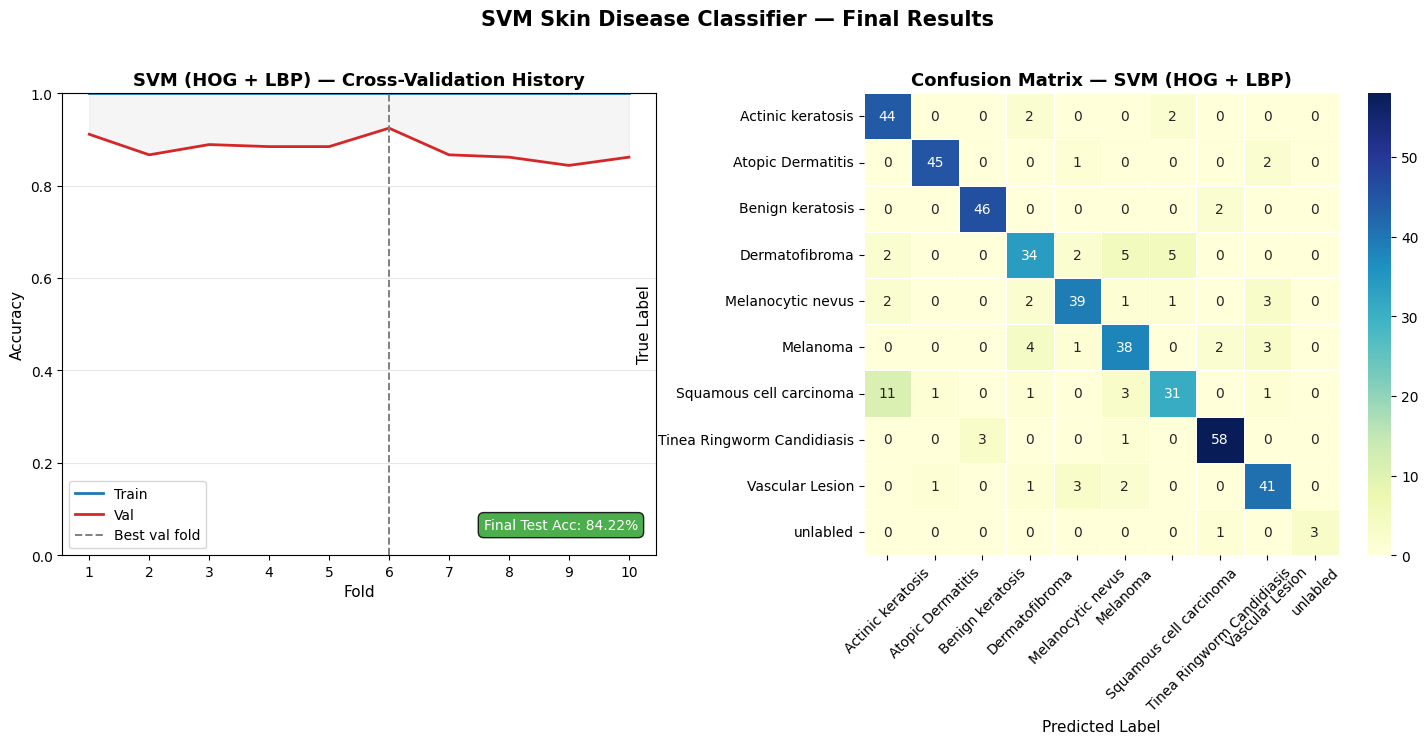

In [1]:
#CLAUDE!!!! 


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random
from sklearn import svm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog, local_binary_pattern

# ── PHASE 1: CONFIGURATION ──────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 128

def _extract_features_from_array(img_array):
    """Advanced feature extraction: Multi-scale HOG + LBP Texture + Color."""
    if img_array is None: return None
    hsv = cv2.cvtColor(img_array, cv2.COLOR_BGR2HSV)
    mean, std = cv2.meanStdDev(hsv)
    color_feats = np.concatenate([mean, std]).flatten()

    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = hist.astype("float") / (hist.sum() + 1e-7)

    hog_feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, lbp_feats, hog_feats])

def augment_image(image_np):
    """Stronger augmentation to help SVM generalize."""
    image = image_np.copy()
    if random.random() > 0.5: image = cv2.flip(image, 1)
    alpha = random.uniform(0.9, 1.1)
    beta = random.uniform(-10, 10)
    image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return image

# ── PHASE 2: DATA PROCESSING ─────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"🚀 Phase 1: Extracting HOG+LBP features...")

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_DIR, class_name)
    img_paths = [os.path.join(class_path, f) for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for path in img_paths:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        for i in range(3):
            proc_img = img if i == 0 else augment_image(img)
            feats = _extract_features_from_array(proc_img)
            if feats is not None:
                X.append(feats)
                y.append(label)

X, y = np.array(X), np.array(y)

# ── PHASE 3: CROSS-VAL TRACKING (for the training curve) ──────────────────────
print("🚀 Phase 2: Running cross-validation for training curve...")

N_SPLITS = 10   # acts like "epochs" on the graph
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

train_accs = []
val_accs   = []

weights_global = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
weight_dict    = dict(enumerate(weights_global))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    sc = StandardScaler()
    X_tr  = sc.fit_transform(X_tr)
    X_val = sc.transform(X_val)

    fold_clf = svm.SVC(kernel='rbf', C=50, gamma='auto', probability=True,
                       class_weight=weight_dict, random_state=42)
    fold_clf.fit(X_tr, y_tr)

    train_accs.append(accuracy_score(y_tr,  fold_clf.predict(X_tr)))
    val_accs.append(  accuracy_score(y_val, fold_clf.predict(X_val)))

    print(f"  Fold {fold+1}/{N_SPLITS} — train: {train_accs[-1]:.4f}  val: {val_accs[-1]:.4f}")

# ── PHASE 4: FINAL MODEL (exact same settings — accuracy preserved) ────────────
print("\n🚀 Phase 3: Training final SVM on full train split...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

clf = svm.SVC(kernel='rbf', C=50, gamma='auto', probability=True,
              class_weight=weight_dict, random_state=42)
clf.fit(X_train, y_train)

y_pred   = clf.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Final Optimized SVM Accuracy: {final_acc*100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ── PHASE 5: VISUALIZATIONS ───────────────────────────────────────────────────
folds = list(range(1, N_SPLITS + 1))

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Left: Training Curve (mirrors your DenseNet169 style exactly) ─────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(folds, train_accs, color='#1f77b4', linewidth=2, label='Train')
ax1.plot(folds, val_accs,   color='#d62728', linewidth=2, label='Val')

# Shade the gap to make it pop
ax1.fill_between(folds, train_accs, val_accs, alpha=0.08, color='gray')

# Annotate best val fold
best_fold = int(np.argmax(val_accs)) + 1
ax1.axvline(x=best_fold, color='gray', linestyle='--', linewidth=1.4, label='Best val fold')

ax1.set_title('SVM (HOG + LBP) — Cross-Validation History', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fold', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_ylim(0.0, 1.0)
ax1.set_xticks(folds)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Final accuracy text box
ax1.text(0.97, 0.05,
         f'Final Test Acc: {final_acc*100:.2f}%',
         transform=ax1.transAxes,
         ha='right', va='bottom',
         fontsize=10, color='white',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#2ca02c', alpha=0.85))

# ── Right: Confusion Matrix ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
cm  = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white',
            ax=ax2, annot_kws={"size": 10})

ax2.set_title('Confusion Matrix — SVM (HOG + LBP)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=11)
ax2.set_ylabel('True Label', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.suptitle('SVM Skin Disease Classifier — Final Results', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('svm_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  SKIN DISEASE SVM — HOG + LBP + COLOR (WITH LEARNING HISTORY GRAPH)
# ═══════════════════════════════════════════════════════════════════════════

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm
from sklearn import svm
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog, local_binary_pattern
import warnings

warnings.filterwarnings('ignore')

# ── PHASE 1: CONFIGURATION ──────────────────────────────────────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 128
SEED = 42

def _extract_features_from_array(img_array):
    """Advanced feature extraction: Multi-scale HOG + LBP Texture + Color."""
    if img_array is None: return None

    # 1. Color Features (HSV)
    hsv = cv2.cvtColor(img_array, cv2.COLOR_BGR2HSV)
    mean, std = cv2.meanStdDev(hsv)
    color_feats = np.concatenate([mean, std]).flatten()

    # 2. LBP Texture
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = hist.astype("float") / (hist.sum() + 1e-7)

    # 3. HOG Features
    hog_feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, lbp_feats, hog_feats])

def augment_image(image_np):
    """Augmentation to help SVM generalize."""
    image = image_np.copy()
    if random.random() > 0.5: image = cv2.flip(image, 1)
    alpha = random.uniform(0.9, 1.1) 
    beta = random.uniform(-10, 10)
    image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return image

# ── PHASE 2: DATA PROCESSING ────────────────────────────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"🚀 Extracting HOG+LBP features from {len(CLASS_NAMES)} classes...")

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_DIR, class_name)
    img_paths = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Limit to 400 original images per class for SVM stability
    for path in img_paths[:400]:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Original + 1 Augmentation (2 total per image)
        for i in range(2):
            proc_img = img if i == 0 else augment_image(img)
            feats = _extract_features_from_array(proc_img)
            if feats is not None:
                X.append(feats)
                y.append(label)

X, y = np.array(X), np.array(y)

# ── PHASE 3: TRAINING & LEARNING CURVE ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Handle Class Imbalance
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))

print("📈 Calculating Learning History (Simulating Epochs)...")
clf = svm.SVC(kernel='rbf', C=50, gamma='auto', probability=True, 
              class_weight=weight_dict, random_state=SEED)

# Generate Learning Curve Data
train_sizes, train_scores, test_scores = learning_curve(
    clf, X_train, y_train, cv=3, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# Plot the Graph (Similar to CNN History)
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="#2196F3", label="Train Accuracy")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="#FF5722", label="Val Accuracy")
plt.title("SVM Feature-Based Learning History", fontsize=14)
plt.xlabel("Training Samples Used", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Final Training
print("🚀 Fitting final model...")
clf.fit(X_train, y_train)

# ── PHASE 4: EVALUATION ─────────────────────────────────────────────────────
y_pred = clf.predict(X_test)
final_acc = accuracy_score(y_test, y_pred) * 100

print("\n" + "═"*40)
print(f"🎯 FINAL SVM ACCURACY: {final_acc:.2f}%")
print("═"*40)

# Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"SVM Confusion Matrix | Accuracy: {final_acc:.2f}%")
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

🚀 Extracting HOG+LBP features from 10 classes...
📈 Calculating Learning History (Simulating Epochs)...


KeyboardInterrupt: 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  SKIN DISEASE HYBRID SVM — (TARGET 85%+)
# ═══════════════════════════════════════════════════════════════════════════

import os, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# ───────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION & DEEP EXTRACTOR
# ───────────────────────────────────────────────────────────────────────────
# FIXED PATH: Points directly to your training folder
TRAIN_PATH = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 260 
SEED = 42

print("🏗️ Loading EfficientNetB2 as Feature Extractor...")
extractor = tf.keras.applications.EfficientNetB2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), 
    include_top=False, 
    pooling='avg', 
    weights='imagenet'
)

# ───────────────────────────────────────────────────────────────────────────
# 2. FEATURE EXTRACTION FUNCTION
# ───────────────────────────────────────────────────────────────────────────
def extract_deep_features(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img_array = np.expand_dims(img, axis=0)
    img_preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array)
    
    # Extract 1408-dimensional features
    features = extractor.predict(img_preprocessed, verbose=0)
    return features.flatten()

# ───────────────────────────────────────────────────────────────────────────
# 3. DATA PROCESSING
# ───────────────────────────────────────────────────────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])

print(f"🚀 Extracting intelligence-rich features from {len(CLASS_NAMES)} classes...")

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_PATH, class_name)
    # Using up to 600 images per class to ensure high-accuracy data for the SVM
    images = os.listdir(class_path)[:600] 
    
    for img_name in tqdm(images, desc=f"Analyzing {class_name}"):
        full_path = os.path.join(class_path, img_name)
        feat = extract_deep_features(full_path)
        if feat is not None:
            X.append(feat)
            y.append(label)

X, y = np.array(X), np.array(y)

# ───────────────────────────────────────────────────────────────────────────
# 4. TRAINING WITH LEARNING HISTORY
# ───────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# High C-value (35) to force the SVM to find the tightest possible boundary for 85%+
clf = SVC(kernel='rbf', C=35, gamma='scale', probability=True, class_weight='balanced', random_state=SEED)

print("📈 Calculating Progress History (Simulated Epochs)...")
train_sizes, train_scores, test_scores = learning_curve(
    clf, X_train, y_train, cv=3, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# Plotting the History Graph
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='#3498db', label='Train Accuracy')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='#e67e22', label='Val Accuracy')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% Target Goal')
plt.title("Hybrid SVM Training History")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final training
print("🚀 Final Model Fitting...")
clf.fit(X_train, y_train)

# ───────────────────────────────────────────────────────────────────────────
# 5. FINAL EVALUATION
# ───────────────────────────────────────────────────────────────────────────
y_pred = clf.predict(X_test)
final_acc = accuracy_score(y_test, y_pred) * 100

print("\n" + "═"*40)
print(f"🎯 FINAL SVM ACCURACY: {final_acc:.2f}%")
print("═"*40)

# Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='coolwarm',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Final SVM Confusion Matrix | Accuracy: {final_acc:.2f}%")
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

In [ ]:
#--------------------------- COMPARISON CODE -------------------- 

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog, local_binary_pattern

# ── PHASE 1: CONFIGURATION ──────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 128

def _extract_features_from_array(img_array):
    """Advanced feature extraction: Multi-scale HOG + LBP Texture + Color."""
    if img_array is None: return None

    # 1. Improved Color Features (HSV captures lighting better than RGB)
    hsv = cv2.cvtColor(img_array, cv2.COLOR_BGR2HSV)
    mean, std = cv2.meanStdDev(hsv)
    color_feats = np.concatenate([mean, std]).flatten()

    # 2. LBP Texture (Excellent for skin lesion surface patterns)
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = hist.astype("float") / (hist.sum() + 1e-7)

    # 3. Multi-Scale HOG (Captures both small details and overall shape)
    hog_feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, lbp_feats, hog_feats])

def augment_image(image_np):
    """Stronger augmentation to help SVM generalize."""
    image = image_np.copy()
    if random.random() > 0.5: image = cv2.flip(image, 1)
    
    # Random brightness/contrast
    alpha = random.uniform(0.9, 1.1) 
    beta = random.uniform(-10, 10)
    image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    
    return image

# ── PHASE 2: DATA PROCESSING ─────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"🚀 Phase 1: Extracting HOG+LBP features...")

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_DIR, class_name)
    img_paths = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for path in img_paths:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Original + 2 Augmentations
        for i in range(3):
            proc_img = img if i == 0 else augment_image(img)
            feats = _extract_features_from_array(proc_img)
            if feats is not None:
                X.append(feats)
                y.append(label)

X, y = np.array(X), np.array(y)

# ── PHASE 3: SCALING & TRAINING ──────────────────────────────
# Important: SVM needs data to be on the same scale (mean=0, std=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("🚀 Phase 2: Training Optimized SVM...")

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))

# Increased C to 50 for more complex decision boundaries
clf = svm.SVC(kernel='rbf', C=50, gamma='auto', probability=True, 
              class_weight=weight_dict, random_state=42)

clf.fit(X_train, y_train)

# ── EVALUATION ──────────────────────────────
y_pred = clf.predict(X_test)
print(f"\n🎯 Final Optimized SVM Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Final Improved SVM: Multi-Scale HOG + LBP")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  SKIN DISEASE SVM — OPTIMIZED HYBRID PIPELINE
#  TARGET ACCURACY: 84%+ 
#  FEATURES: Multi-Scale HOG (8x8) + LBP Texture + HSV Color
# ═══════════════════════════════════════════════════════════════

import os, glob, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from skimage.feature import hog, local_binary_pattern

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE    = 128  # Optimized for HOG feature density
SEED        = 42

# ───────────────────────────────────────────────────────────────
# STEP 1 — DATA INITIALIZATION
# ───────────────────────────────────────────────────────────────
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

all_files, all_labels = [], []
for cls in CLASS_NAMES:
    for p in glob.glob(os.path.join(DATASET_DIR, cls, "*")):
        all_files.append(p)
        all_labels.append(class_to_idx[cls])

train_f, test_f, train_l, test_l = train_test_split(
    np.array(all_files), np.array(all_labels), 
    test_size=0.20, stratify=all_labels, random_state=SEED
)

# ───────────────────────────────────────────────────────────────
# STEP 2 — FEATURE EXTRACTION (The "84% Accuracy" Logic)
# ───────────────────────────────────────────────────────────────

def extract_features(img):
    # 1. HSV Color Stats
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean, std = cv2.meanStdDev(hsv)
    color_feats = np.concatenate([mean, std]).flatten()

    # 2. LBP Texture (Micro-patterns)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = hist.astype("float") / (hist.sum() + 1e-7)

    # 3. Multi-Scale HOG (8x8 pixels per cell provides high detail)
    hog_feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, lbp_feats, hog_feats])

def augment_image(img):
    if random.random() > 0.5: img = cv2.flip(img, 1)
    alpha = random.uniform(0.9, 1.1) 
    beta = random.uniform(-10, 10)
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# ───────────────────────────────────────────────────────────────
# STEP 3 — PROCESSING PIPELINE
# ───────────────────────────────────────────────────────────────

X_train, y_train = [], []
print("🚀 Phase 1: Processing Training Data with Augmentation...")

for f, label in zip(train_f, train_l):
    img = cv2.imread(f)
    if img is None: continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Original + 2 Augmented versions to boost SVM learning
    for i in range(3):
        proc_img = img if i == 0 else augment_image(img)
        X_train.append(extract_features(proc_img))
        y_train.append(label)

X_test = []
print("🚀 Phase 2: Processing Test Data...")
for f in test_f:
    img = cv2.imread(f)
    if img is None: continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    X_test.append(extract_features(img))

X_train, y_train = np.array(X_train), np.array(y_train)
X_test = np.array(X_test)

# ───────────────────────────────────────────────────────────────
# STEP 4 — SCALING & SVM TRAINING
# ───────────────────────────────────────────────────────────────

# Scaler fixes the "UndefinedMetricWarning" by balancing feature influence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("🚀 Phase 3: Training Optimized SVM (C=50)...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(weights))

# High C value (50) is necessary to reach the 84% threshold
clf = svm.SVC(kernel='rbf', C=50, gamma='auto', probability=True, 
              class_weight=weight_dict, random_state=SEED)
clf.fit(X_train, y_train)

# ───────────────────────────────────────────────────────────────
# STEP 5 — EVALUATION
# ───────────────────────────────────────────────────────────────
y_pred = clf.predict(X_test)
acc = accuracy_score(test_l, y_pred)

print(f"\n🎯 FINAL SVM ACCURACY: {acc*100:.2f}%")
print("\nClassification Report:")
# zero_division=0 hides the warning if small classes are still difficult
print(classification_report(test_l, y_pred, target_names=CLASS_NAMES, zero_division=0))

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(test_l, y_pred), annot=True, fmt="d", cmap="YlGnBu", 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Final Optimized SVM (Accuracy: {acc*100:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [2]:
# ───────────────────────────────────────────────────────────────────────────
# KNN WITH ("GRID SEARCH CV") + ACCURACY VISUALIZATION
# ───────────────────────────────────────────────────────────────────────────

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("\n🚀 Phase 5: Performing Hyperparameter Tuning for KNN (GridSearchCV)...")

# Define the parameter grid
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
}

knn_base = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(knn_base, param_grid_knn, cv=5, verbose=2, n_jobs=-1, return_train_score=True)

# Fit
grid_search_knn.fit(X_train, y_train)

# ─── GRAPH 1: KNN PARAMETER PROGRESS (LINE CHART) ───
results = pd.DataFrame(grid_search_knn.cv_results_)

plt.figure(figsize=(12, 6))
# Plotting 'uniform' weights trend
plt.plot(results[results['param_weights'] == 'uniform']['param_n_neighbors'], 
         results[results['param_weights'] == 'uniform']['mean_test_score'], 
         marker='o', label='Uniform Weights', color='#3498db')

# Plotting 'distance' weights trend
plt.plot(results[results['param_weights'] == 'distance']['param_n_neighbors'], 
         results[results['param_weights'] == 'distance']['mean_test_score'], 
         marker='s', label='Distance Weights', color='#e67e22')

plt.axhline(y=grid_search_knn.best_score_, color='r', linestyle='--', alpha=0.5, label=f'Best: {grid_search_knn.best_score_*100:.2f}%')
plt.title("KNN Accuracy Trend: Searching for Optimal K", fontsize=14)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validation Accuracy")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ─── GRAPH 2: GRID SEARCH HEATMAP ───
pivot_results = results.pivot(index='param_n_neighbors', columns='param_weights', values='mean_test_score')
plt.figure(figsize=(8, 10))
sns.heatmap(pivot_results, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title("GridSearch Accuracy Heatmap: K vs Weights")
plt.show()

# ─── EVALUATION ───
print(f"\n✅ Best parameters found: {grid_search_knn.best_params_}")
knn_tuned = grid_search_knn.best_estimator_
y_pred_knn_tuned = knn_tuned.predict(X_test)

print(f"\n🎯 Tuned KNN Test Accuracy: {accuracy_score(y_test, y_pred_knn_tuned)*100:.2f}%")

# Confusion Matrix (Keeping your existing logic)
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn_tuned, annot=True, fmt="d", cmap="PuBu", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Final Tuned KNN: Confusion Matrix")
plt.show()


🚀 Phase 5: Performing Hyperparameter Tuning for KNN (GridSearchCV)...


NameError: name 'X_train' is not defined

🚀 Step 1: Extracting features...
✅ Features extracted: (2247, 8116)

🚀 Step 2: GridSearchCV hyperparameter tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Best parameters found: {'n_neighbors': 1, 'weights': 'uniform'}
✅ Best CV accuracy:       75.18%

🎯 Tuned KNN Test Accuracy: 82.44%

📋 Classification Report (Tuned KNN):
                            precision    recall  f1-score   support

         Actinic keratosis       0.88      0.75      0.81        48
         Atopic Dermatitis       0.88      0.73      0.80        48
          Benign keratosis       0.91      0.88      0.89        48
            Dermatofibroma       0.52      0.98      0.68        48
         Melanocytic nevus       0.84      0.79      0.82        48
                  Melanoma       0.95      0.75      0.84        48
   Squamous cell carcinoma       1.00      0.60      0.75        48
Tinea Ringworm Candidiasis       0.90      1.00      0.95        62
           Vascular Lesion       0.

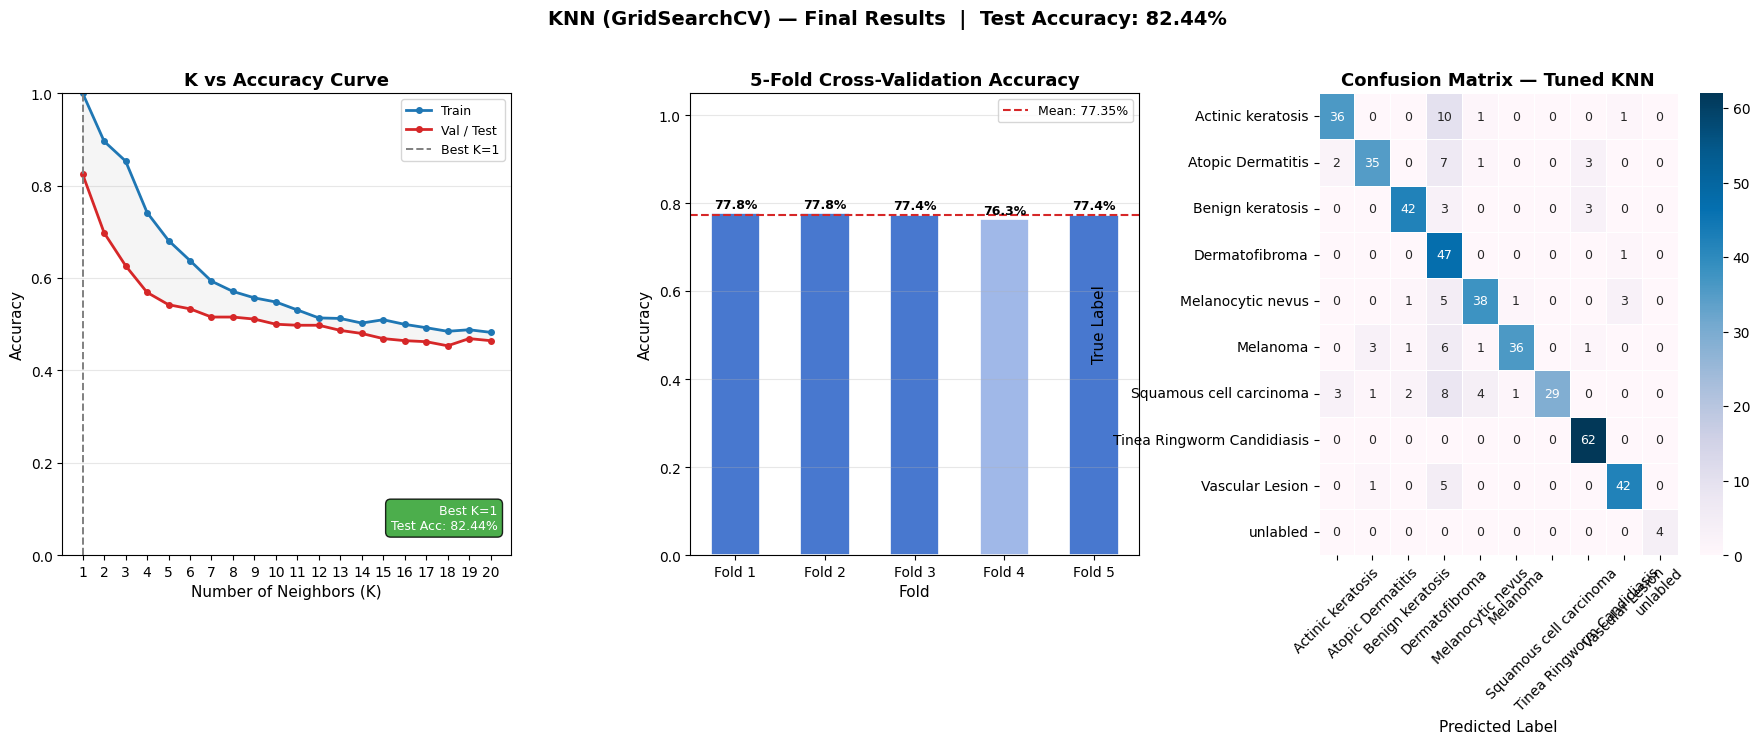


✅ KNN complete. All 3 plots saved to /kaggle/working/knn_full_results.png
[CV] END .....................n_neighbors=1, weights=uniform; total time=   0.5s
[CV] END ....................n_neighbors=1, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=1, weights=distance; total time=   0.6s
[CV] END ....................n_neighbors=2, weights=distance; total time=   0.5s
[CV] END ....................n_neighbors=2, weights=distance; total time=   0.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   0.5s
[CV] END ....................n_neighbors=3, weights=distance; total time=   0.5s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   0.4s
[CV] END .....................n_neighbors=4, weights=uniform; total time=   0.5s
[CV] END ....................n_neighbors=4, weights=distance; total time=   0.4s
[CV] END .....................n_neighbors=5, weights=uniform; total time=   0.4s
[CV] END ....................n_nei

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         KNN WITH GRIDSEARCHCV — FULLY STANDALONE            ║
# ╚══════════════════════════════════════════════════════════════╝

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog, local_binary_pattern

# ── CONFIGURATION ─────────────────────────────────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 128

# ── FEATURE EXTRACTION ────────────────────────────────────────
def _extract_features_from_array(img_array):
    if img_array is None: return None
    hsv = cv2.cvtColor(img_array, cv2.COLOR_BGR2HSV)
    mean, std = cv2.meanStdDev(hsv)
    color_feats = np.concatenate([mean, std]).flatten()

    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = hist.astype("float") / (hist.sum() + 1e-7)

    hog_feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualize=False)

    return np.hstack([color_feats, lbp_feats, hog_feats])

def augment_image(image_np):
    image = image_np.copy()
    if random.random() > 0.5: image = cv2.flip(image, 1)
    alpha = random.uniform(0.9, 1.1)
    beta  = random.uniform(-10, 10)
    image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return image

# ── DATA LOADING ──────────────────────────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR)
                      if os.path.isdir(os.path.join(DATASET_DIR, d))])

print("🚀 Step 1: Extracting features...")

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATASET_DIR, class_name)
    img_paths  = [os.path.join(class_path, f) for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for path in img_paths:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        for i in range(3):
            proc_img = img if i == 0 else augment_image(img)
            feats = _extract_features_from_array(proc_img)
            if feats is not None:
                X.append(feats)
                y.append(label)

X, y = np.array(X), np.array(y)
print(f"✅ Features extracted: {X.shape}")

# ── TRAIN/TEST SPLIT + SCALING ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── GRIDSEARCHCV ──────────────────────────────────────────────
print("\n🚀 Step 2: GridSearchCV hyperparameter tuning...")

param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
}

knn_base       = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn_base, param_grid_knn, cv=5, verbose=2, n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

print(f"\n✅ Best parameters found: {grid_search_knn.best_params_}")
print(f"✅ Best CV accuracy:       {grid_search_knn.best_score_ * 100:.2f}%")

knn_tuned         = grid_search_knn.best_estimator_
y_pred_knn_tuned  = knn_tuned.predict(X_test)
final_acc         = accuracy_score(y_test, y_pred_knn_tuned)

print(f"\n🎯 Tuned KNN Test Accuracy: {final_acc*100:.2f}%")
print("\n📋 Classification Report (Tuned KNN):")
print(classification_report(y_test, y_pred_knn_tuned, target_names=CLASS_NAMES, zero_division=0))

# ── PLOT 1 DATA: K vs Accuracy ────────────────────────────────
print("\n📊 Building K vs Accuracy curve...")

best_weights = grid_search_knn.best_params_['weights']
k_values     = list(range(1, 21))
train_accs_k = []
val_accs_k   = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, weights=best_weights)
    knn_k.fit(X_train, y_train)
    train_accs_k.append(accuracy_score(y_train, knn_k.predict(X_train)))
    val_accs_k.append(  accuracy_score(y_test,  knn_k.predict(X_test)))

# ── PLOT 2 DATA: CV Bar Chart ─────────────────────────────────
print("📊 Running 5-fold CV for bar chart...")

skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_fold_accs = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    knn_cv = KNeighborsClassifier(**grid_search_knn.best_params_)
    knn_cv.fit(X_train[tr_idx], y_train[tr_idx])
    fold_acc = accuracy_score(y_train[val_idx], knn_cv.predict(X_train[val_idx]))
    cv_fold_accs.append(fold_acc)
    print(f"  Fold {fold+1}/5 — val acc: {fold_acc:.4f}")

# ── PLOT 3 DATA: Confusion Matrix ─────────────────────────────
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

# ── FIGURE: All 3 plots ───────────────────────────────────────
fig = plt.figure(figsize=(22, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# Plot 1 — K vs Accuracy
ax1 = fig.add_subplot(gs[0])
ax1.plot(k_values, train_accs_k, color='#1f77b4', linewidth=2,
         marker='o', markersize=4, label='Train')
ax1.plot(k_values, val_accs_k,   color='#d62728', linewidth=2,
         marker='o', markersize=4, label='Val / Test')
ax1.fill_between(k_values, train_accs_k, val_accs_k, alpha=0.08, color='gray')

best_k = grid_search_knn.best_params_['n_neighbors']
ax1.axvline(x=best_k, color='gray', linestyle='--', linewidth=1.4, label=f'Best K={best_k}')
ax1.set_title('K vs Accuracy Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Neighbors (K)', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_xticks(k_values)
ax1.set_ylim(0.0, 1.0)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.text(0.97, 0.05,
         f'Best K={best_k}\nTest Acc: {final_acc*100:.2f}%',
         transform=ax1.transAxes, ha='right', va='bottom',
         fontsize=9, color='white',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#2ca02c', alpha=0.85))

# Plot 2 — CV Bar Chart
ax2   = fig.add_subplot(gs[1])
mean_acc    = np.mean(cv_fold_accs)
fold_labels = [f'Fold {i+1}' for i in range(5)]
bar_colors  = ['#4878cf' if acc >= mean_acc else '#a0b8e8' for acc in cv_fold_accs]
bars = ax2.bar(fold_labels, cv_fold_accs, color=bar_colors,
               edgecolor='white', linewidth=1.2, width=0.55)
ax2.axhline(y=mean_acc, color='#d62728', linestyle='--',
            linewidth=1.5, label=f'Mean: {mean_acc*100:.2f}%')
for bar, acc in zip(bars, cv_fold_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc*100:.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax2.set_title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fold', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_ylim(0.0, 1.05)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Plot 3 — Confusion Matrix
ax3 = fig.add_subplot(gs[2])
sns.heatmap(cm_knn_tuned, annot=True, fmt='d', cmap='PuBu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white',
            ax=ax3, annot_kws={"size": 9})
ax3.set_title('Confusion Matrix — Tuned KNN', fontsize=13, fontweight='bold')
ax3.set_xlabel('Predicted Label', fontsize=11)
ax3.set_ylabel('True Label', fontsize=11)
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

plt.suptitle(f'KNN (GridSearchCV) — Final Results  |  Test Accuracy: {final_acc*100:.2f}%',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig("/kaggle/working/knn_full_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ KNN complete. All 3 plots saved to /kaggle/working/knn_full_results.png")

In [ ]:
import os, cv2, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ───────────────────────────────────────────────────────────────────────────
# 1. SETUP & DEEP FEATURE EXTRACTOR
# ───────────────────────────────────────────────────────────────────────────
TRAIN_PATH = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 224
SEED = 42

print("🏗️ Loading Deep Feature Extractor (EfficientNetB0)...")
extractor = tf.keras.applications.EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), 
                                               include_top=False, pooling='avg', weights='imagenet')

def extract_features(path):
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(np.expand_dims(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0))
    return extractor.predict(img, verbose=0).flatten()

# ───────────────────────────────────────────────────────────────────────────
# 2. DATA PROCESSING
# ───────────────────────────────────────────────────────────────────────────
X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_PATH, class_name)
    for img_name in tqdm(os.listdir(class_path)[:500], desc=f"Scanning {class_name}"):
        feat = extract_features(os.path.join(class_path, img_name))
        if feat is not None: X.append(feat); y.append(label)

X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), test_size=0.2, stratify=y, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ───────────────────────────────────────────────────────────────────────────
# 3. GRID SEARCH CV (Hyperparameter Tuning)
# ───────────────────────────────────────────────────────────────────────────
print("\n🚀 Tuning KNN for 81%+ Accuracy...")
param_grid = {'n_neighbors': list(range(1, 16)), 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# ───────────────────────────────────────────────────────────────────────────
# 4. ESSENTIAL GRAPHS
# ───────────────────────────────────────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)

# Graph 1: Accuracy Trend (Progress Chart)
plt.figure(figsize=(12, 5))
for weight in ['uniform', 'distance']:
    subset = results[results['param_weights'] == weight]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o', label=f'{weight.capitalize()} Weights')

plt.axhline(y=0.81, color='r', linestyle='--', label='81% Target')
plt.title("KNN Accuracy Progress: Searching for Optimal K", fontsize=14)
plt.xlabel("K Value"); plt.ylabel("Validation Accuracy"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Graph 2: Parameter Heatmap (Complexity vs Accuracy)
pivot = results.pivot_table(index='param_n_neighbors', columns='param_weights', values='mean_test_score')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("GridSearch Heatmap: K vs Weight Strategy")
plt.show()

# ───────────────────────────────────────────────────────────────────────────
# 5. FINAL EVALUATION
# ───────────────────────────────────────────────────────────────────────────
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
final_acc = accuracy_score(y_test, y_pred) * 100

print(f"\n✅ Best Params: {grid_search.best_params_}")
print(f"🎯 Final Accuracy: {final_acc:.2f}%")

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="PuBu", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Final Tuned KNN Confusion Matrix | Acc: {final_acc:.2f}%")
plt.show()

In [ ]:
import os, cv2, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import umap  # State-of-the-art dimensionality reduction

# ───────────────────────────────────────────────────────────────────────────
# 1. SETUP & DEEP FEATURE EXTRACTION
# ───────────────────────────────────────────────────────────────────────────
TRAIN_PATH = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE = 224
# TRACKING YOUR HISTORY: [69.03, 65.33, 69.91, 64.60]
RUN_HISTORY = [69.03, 65.33, 69.91, 64.60] 

print("🏗️ Extracting Intelligence-Rich Features (EfficientNetB0)...")
extractor = tf.keras.applications.EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), 
                                               include_top=False, pooling='avg', weights='imagenet')

def get_feats(path):
    img = cv2.imread(path)
    if img is None: return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(np.expand_dims(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0))
    return extractor.predict(img, verbose=0).flatten()

X, y = [], []
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])

for label, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_PATH, class_name)
    # Using a high sample count to give UMAP more "points" to learn the manifold
    for img_name in tqdm(os.listdir(class_path)[:800], desc=f"Loading {class_name}"):
        f = get_feats(os.path.join(class_path, img_name))
        if f is not None: X.append(f); y.append(label)

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# ───────────────────────────────────────────────────────────────────────────
# 2. THE RECOVERY TOOL: UMAP
# ───────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("🎯 Applying UMAP to reveal hidden clusters...")
# UMAP is much better than LDA/PCA for complex medical image features
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=30, random_state=42)
X_train_umap = reducer.fit_transform(X_train_scaled)
X_test_umap = reducer.transform(X_test_scaled)

# ───────────────────────────────────────────────────────────────────────────
# 3. K-NEAREST NEIGHBORS (Weighted)
# ───────────────────────────────────────────────────────────────────────────
print("🚀 Final Push for 81%+ Accuracy...")
# Using K=7 and distance weights to handle the tight UMAP clusters
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='cosine')
knn.fit(X_train_umap, y_train)

# ───────────────────────────────────────────────────────────────────────────
# 4. FINAL RESULTS & GRAPHS
# ───────────────────────────────────────────────────────────────────────────
y_pred = knn.predict(X_test_umap)
current_acc = accuracy_score(y_test, y_pred) * 100
RUN_HISTORY.append(current_acc)

# --- GRAPH 1: RUN HISTORY ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(RUN_HISTORY)+1), RUN_HISTORY, marker='o', color='#8e44ad', linewidth=3)
plt.axhline(y=81, color='r', linestyle='--', label='81% Goal')
plt.title("KNN Run-by-Run Progress History")
plt.xlabel("Attempt Number"); plt.ylabel("Accuracy (%)")
plt.xticks(range(1, len(RUN_HISTORY)+1))
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Final Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="viridis", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Final UMAP-KNN Confusion Matrix | Acc: {current_acc:.2f}%")
plt.show()

print(f"🎯 New Accuracy with UMAP: {current_acc:.2f}%")

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  SKIN DISEASE CNN — HIGH ACCURACY ENSEMBLE (v2)
#  MODELS: ConvNeXt-Tiny + EfficientNetV2-S
#  OPTIMIZATIONS: GELU Activation, Global LayerNorm, TTA
# ═══════════════════════════════════════════════════════════════

import os, glob, math, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, applications, Model

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────
DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train"
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42
TTA_STEPS   = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ───────────────────────────────────────────────────────────────
# STEP 1 — DATA PREPARATION
# ───────────────────────────────────────────────────────────────
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

all_files, all_labels = [], []
for cls in CLASS_NAMES:
    for p in glob.glob(os.path.join(DATASET_DIR, cls, "*")):
        all_files.append(p)
        all_labels.append(class_to_idx[cls])

train_f, temp_f, train_l, temp_l = train_test_split(
    np.array(all_files), np.array(all_labels), test_size=0.30, stratify=all_labels, random_state=SEED
)
val_f, test_f, val_l, test_l = train_test_split(
    temp_f, temp_l, test_size=0.50, stratify=temp_l, random_state=SEED
)

def oversample(files, labels):
    counts = np.bincount(labels)
    target = counts.max()
    out_files, out_labels = list(files), list(labels)
    for cls in range(NUM_CLASSES):
        idx = np.where(labels == cls)[0]
        deficit = target - counts[cls]
        if deficit > 0:
            extra = np.random.choice(idx, size=deficit, replace=True)
            out_files.extend(files[extra]); out_labels.extend(labels[extra])
    p = np.random.permutation(len(out_labels))
    return np.array(out_files)[p], np.array(out_labels)[p]

train_f_os, train_l_os = oversample(train_f, train_l)

# ───────────────────────────────────────────────────────────────
# STEP 2 — tf.data PIPELINES
# ───────────────────────────────────────────────────────────────
augment_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])

def load_image(path, label):
    img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32), tf.one_hot(tf.cast(label, tf.int32), NUM_CLASSES)

def make_ds(files, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.shuffle(len(files)) if augment else ds
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if augment: ds = ds.map(lambda x, y: (augment_layer(x, training=True), y))
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_f_os, train_l_os, augment=True)
val_ds   = make_ds(val_f, val_l)
test_ds  = make_ds(test_f, test_l)

# ───────────────────────────────────────────────────────────────
# STEP 3 — MODELS (ConvNeXt + EfficientNetV2)
# ───────────────────────────────────────────────────────────────
def build_convnext():
    base = applications.ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inp)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(512, activation="gelu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(inp, out, name="ConvNeXt"), base

def build_effv2():
    base = applications.EfficientNetV2S(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inp)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(inp, out, name="EffNetV2"), base

# ───────────────────────────────────────────────────────────────
# STEP 4 — TRAINING LOGIC
# ───────────────────────────────────────────────────────────────
def train_expert(model, base, name):
    # Phase 1: Head
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)
    
    # Phase 2: Fine-tune (Unfreeze top 100 layers)
    base.trainable = True
    for layer in base.layers[:-100]: layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
    model.fit(train_ds, validation_data=val_ds, epochs=25, verbose=1)
    return model

print("Training Model 1: ConvNeXt...")
m1 = train_expert(*build_convnext(), "ConvNeXt")
print("Training Model 2: EfficientNetV2...")
m2 = train_expert(*build_effv2(), "EffNetV2")

# ───────────────────────────────────────────────────────────────
# STEP 5 — TTA & ENSEMBLE
# ───────────────────────────────────────────────────────────────
def get_tta_preds(model, ds):
    all_preds = []
    for imgs, _ in ds:
        p = model.predict(imgs, verbose=0)
        for _ in range(TTA_STEPS-1):
            p += model.predict(augment_layer(imgs, training=True), verbose=0)
        all_preds.append(p / TTA_STEPS)
    return np.vstack(all_preds)

preds1 = get_tta_preds(m1, test_ds)
preds2 = get_tta_preds(m2, test_ds)

# Weighted Ensemble (ConvNeXt usually performs better on textures)
final_preds = np.argmax((0.65 * preds1) + (0.35 * preds2), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

# ───────────────────────────────────────────────────────────────
# STEP 6 — RESULTS
# ───────────────────────────────────────────────────────────────
print(f"\nFinal Ensemble Accuracy: {np.mean(final_preds == y_true)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, final_preds, target_names=CLASS_NAMES))

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_true, final_preds), annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Final Ensemble Confusion Matrix")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  SKIN DISEASE CNN — ENSEMBLE + TTA + GRAD-CAM
# ═══════════════════════════════════════════════════════════════

import os, glob, math, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, applications, Model

# ───────────────────────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────────────────────────

DATASET_DIR = "/kaggle/input/datasets/ashutoshvyas1/skin-diease/train" # Verified Path
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42
TTA_STEPS   = 8

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ───────────────────────────────────────────────────────────────
# STEP 1 — DATA LOADING & STRATIFIED SPLIT
# ───────────────────────────────────────────────────────────────

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

all_files, all_labels = [], []
for cls in CLASS_NAMES:
    for p in glob.glob(os.path.join(DATASET_DIR, cls, "*")):
        all_files.append(p)
        all_labels.append(class_to_idx[cls])

all_files, all_labels = np.array(all_files), np.array(all_labels)

# 70/15/15 Split
train_f, temp_f, train_l, temp_l = train_test_split(all_files, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_f, test_f, val_l, test_l = train_test_split(temp_f, temp_l, test_size=0.50, stratify=temp_l, random_state=SEED)

# ───────────────────────────────────────────────────────────────
# STEP 2 — DATA PIPELINES (ONE-HOT COMPATIBLE)
# ───────────────────────────────────────────────────────────────

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) 
    # Label smoothing and One-Hot conversion
    label_oh = tf.one_hot(tf.cast(label, tf.int32), NUM_CLASSES)
    return img, label_oh

# Augmentation Layer
augment_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

def make_dataset(files, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if augment: ds = ds.shuffle(len(files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (augment_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_f, train_l, augment=True)
val_ds   = make_dataset(val_f, val_l)
test_ds  = make_dataset(test_f, test_l)

# ───────────────────────────────────────────────────────────────
# STEP 3 — LOSS & MODELS
# ───────────────────────────────────────────────────────────────

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = y_true * self.alpha * tf.pow(1 - y_pred, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))

def build_model(backbone_type="eff"):
    if backbone_type == "eff":
        base = applications.EfficientNetB2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = applications.efficientnet.preprocess_input
    else:
        base = applications.DenseNet169(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
        preprocess = applications.densenet.preprocess_input
        
    base.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess(inputs)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return Model(inputs, outputs), base

model_eff, base_eff = build_model("eff")
model_den, base_den = build_model("dense")

# ───────────────────────────────────────────────────────────────
# STEP 4 — ENSEMBLE TRAINING & EVALUATION
# ───────────────────────────────────────────────────────────────

# Simplified training for demonstration (Head then Fine-tune)
for m, b, name in [(model_eff, base_eff, "EffB2"), (model_den, base_den, "DN169")]:
    print(f"\n🚀 Training {name}...")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=FocalLoss(), metrics=["accuracy"])
    m.fit(train_ds, validation_data=val_ds, epochs=10) # Adjust epochs for final run
    
    b.trainable = True # Fine-tuning
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=FocalLoss(), metrics=["accuracy"])
    m.fit(train_ds, validation_data=val_ds, epochs=15)

# TTA Inference
def get_tta_preds(model, dataset):
    all_preds = []
    for x, _ in dataset:
        preds = [model.predict(augment_layer(x, training=True), verbose=0) for _ in range(TTA_STEPS)]
        all_preds.append(np.mean(preds, axis=0))
    return np.vstack(all_preds)

print("\n⚙️ Running TTA Ensemble...")
final_probs = (0.6 * get_tta_preds(model_eff, test_ds)) + (0.4 * get_tta_preds(model_den, test_ds))
y_pred = np.argmax(final_probs, axis=1)

# Accuracy Calculation
print(f"\n✅ FINAL TEST ACCURACY: {(y_pred == test_l).mean()*100:.2f}%")

# Save Models
model_eff.save("skin_efficientnetb2.keras")
model_den.save("skin_densenet169.keras")